# Series sintéticas F3+nexp con LMP y comparación con datos reales

Este notebook reutiliza la lógica del script **`new-perturbation-data-inversion-bbo_F3_nexp_fixed_CLEAN_v3.jl`** para:

1. cargar los **datos reales** (`baseline + detrended`),
2. generar las **series sintéticas perturbadas** de amplitud y fase con **LMP**,
3. generar también las **series background** (sin perturbación),
4. comparar las series en el mismo eje temporal.

## Supuesto operativo
Ejecuta este notebook desde la **carpeta raíz del proyecto**, la misma donde existen:

- `./mytools/preamble.jl`
- `./mytools/scenario.jl`
- `./reference-efield-firi.jld2`
- `./datos_asls_full-v3.h5`

## Importante
El script compartido **no trae hardcodeados los `reco_params` finales**; lo que sí trae explícitamente son los parámetros semilla **`pars0`**.  
Por eso, este notebook usa **`pars0 = [amp0, t_pk0, τ_u0, τ_d0, eps0, z0_0, hz_0]`** como parámetros de la perturbación sintética.


In [1]:
# ============================================================
# 1) CARGA DEL ENTORNO Y FUNCIONES AUXILIARES
# ============================================================
PROJECT_ROOT = pwd()

@assert isfile(joinpath(PROJECT_ROOT, "mytools", "preamble.jl")) "Ejecuta el notebook desde la carpeta raíz del proyecto."
@assert isfile(joinpath(PROJECT_ROOT, "mytools", "scenario.jl")) "No se encontró scenario.jl en ./mytools/"

include(joinpath(PROJECT_ROOT, "mytools", "preamble.jl"))
include(joinpath(PROJECT_ROOT, "mytools", "scenario.jl"))

using Dates
using TimeZones
using AstroLib
using DSP
using JLD2
using HDF5
using Polynomials
using LinearAlgebra
using CairoMakie
using Interpolations: LinearInterpolation

BLAS.set_num_threads(1)

Base.@kwdef struct SimCache
    tx::Any
    rx::Any
    rx_rec::Any
    ground::Any
    dists12::Vector{Float64}
    dists22::Vector{Float64}
    dt::Vector{ZonedDateTime}
    bf_list::Vector{Any}
end

function build_cache(ts, tx, rx, rx_rec, ground, dists_new)
    dt = ZonedDateTime.(unix2datetime.(ts), tz"UTC")
    d12 = dists_new[1:2:end]
    d22 = dists_new[2:2:end]
    bf_list = [igrf(tx, rx_rec, year(ti), d22; alt=60e3) for ti in dt]
    return SimCache(tx=tx, rx=rx, rx_rec=rx_rec, ground=ground,
                    dists12=d12, dists22=d22, dt=dt, bf_list=bf_list)
end

"""
    chi_signed_astrolib(lat_deg, lon_deg, zdt; height_m=0.0, units=:deg)

Ángulo solar zenital con signo estilo LWPC:
- χ < 0 : mañana / Este
- χ > 0 : tarde / Oeste
"""
function chi_signed_astrolib(lat_deg::Real, lon_deg::Real, zdt::ZonedDateTime;
                             height_m::Real=0.0, units::Symbol=:deg)
    zdt_utc = astimezone(zdt, tz"UTC")
    jd  = AstroLib.jdcnv(DateTime(zdt_utc))
    ra, dec = AstroLib.sunpos(jd)
    alt_deg, az_deg, _ha_deg = AstroLib.eq2hor(ra, dec, jd, lat_deg, lon_deg, height_m)
    sza = 90.0 - alt_deg
    chi_deg = (0.0 <= az_deg < 180.0) ? -sza : +sza
    return units === :rad ? deg2rad(chi_deg) : chi_deg
end

const LinBC = Interpolations.Linear()

function unwrap_resampled(
    t_ref::Vector{ZonedDateTime}, phi_wr_ref::AbstractVector{<:Real},
    t_new::Vector{ZonedDateTime}, phi_wr_new::AbstractVector{<:Real};
    discont = 0.9*π
)
    @assert length(t_ref) == length(phi_wr_ref)
    @assert length(t_new) == length(phi_wr_new)
    @assert issorted(t_ref)
    @assert issorted(t_new)

    phi_ref_unw = DSP.unwrap(collect(float.(phi_wr_ref)); dims=1, discont=discont, period=2π)

    to_ms(zdt_vec) = Float64.(Dates.value.(DateTime.(astimezone.(zdt_vec, Ref(tz"UTC")))))
    x_ref = to_ms(t_ref)
    x_new = to_ms(t_new)

    itp_phi = LinearInterpolation(x_ref, phi_ref_unw; extrapolation_bc=LinBC)
    phi_ref_at_new = itp_phi.(x_new)

    phi_wr_new_f = collect(float.(phi_wr_new))
    phi_unw_new  = similar(phi_wr_new_f)
    @inbounds for k in eachindex(phi_wr_new_f)
        m = round((phi_ref_at_new[k] - phi_wr_new_f[k]) / (2*π))
        phi_unw_new[k] = phi_wr_new_f[k] + m*2*π
    end
    return phi_unw_new
end

function nearest_time_index(tvec::Vector{ZonedDateTime}, t::ZonedDateTime)
    Δ = abs.(Dates.value.(DateTime.(tvec) .- DateTime(t)))
    return argmin(Δ)
end


[ Info: Loading CHAOS-7.11.mat


Geodesic Distance from WWVB to PLO: 6568.28 km
Geodesic Distance from WWVB to PIU: 5659.0 km
Geodesic Distance from NAA to PLO: 6568.28 km
Geodesic Distance from NAA to PIU: 5659.0 km
Initial time: 2008-01-10T10:00:00+00:00
Scenario defined.
Datetime range: from 2008-01-10 10:00:00 UTC to 2008-01-11 10:00:00 UTC with a length of 289.


nearest_time_index (generic function with 1 method)

In [2]:
# ============================================================
# 2) CARGA DE REFERENCIA FIRI, DATOS REALES Y DEFINICIÓN F3+nexp
# ============================================================
filename_ref = joinpath(PROJECT_ROOT, "reference-efield-firi.jld2")
@assert isfile(filename_ref) "No existe reference-efield-firi.jld2"

jldfile_ref = jldopen(filename_ref, "r")
A_firi_ref = jldfile_ref["amp"]
phi_firi_wrapped_ref = jldfile_ref["phi"]
zdt_ref = jldfile_ref["zdt"]
close(jldfile_ref)

filename_asls = joinpath(PROJECT_ROOT, "datos_asls_full-v3.h5")
@assert isfile(filename_asls) "No existe datos_asls_full-v3.h5"

baseline_asls_amp  = h5read(filename_asls, "baseline_asls_amp")
baseline_asls_phi  = h5read(filename_asls, "baseline_asls_phi")
detrended_asls_amp = h5read(filename_asls, "detrended_asls_amp")
detrended_asls_phi = h5read(filename_asls, "detrended_asls_phi")
time_unix          = h5read(filename_asls, "time_unix")

epoch      = DateTime(1970,1,1)
dt_utc     = epoch .+ Second.(time_unix)
time_zoned = ZonedDateTime.(dt_utc, tz"UTC")

baseline_amp  = baseline_asls_amp
baseline_phi  = baseline_asls_phi
amp_detrended = detrended_asls_amp
phi_detrended = detrended_asls_phi

z = collect(alt) ./ 1e3
t_step = Minute(1)#Minute(5)
zdt0 = ZonedDateTime(2008, 3, 25, 18, 0, 0, tz"UTC")
zdt = datelinspace(zdt0, zdt0 + Hour(4), t_step)

t₀ = ZonedDateTime(2008, 3, 25, 18, 30, 0, tz"UTC")

@inline nexp(z_km::Real, z0::Real, hz::Real) = exp(clamp((z_km - z0) / hz, -50.0, 50.0))

@inline function gauss_asym_F3(Δt::Real, amp::Real, t_pk::Real, τ_u::Real, τ_d::Real, eps_t::Real)
    w = τ_u + 0.5 * (τ_d - τ_u) * (1.0 + tanh((Δt - t_pk) / eps_t))
    return amp * exp(-0.5 * ((Δt - t_pk) / w)^2)
end

@inline function ne_perturb_f3(z::Real, h_i::Real, β_i::Real, Δt::Real,
                               amp::Real, t_pk::Real, τ_u::Real, τ_d::Real, eps_t::Real,
                               z0::Real, hz::Real)
    ne_bg = waitprofile(z, h_i, β_i)
    return ne_bg * (1 + nexp(z/1e3, z0, hz) * gauss_asym_F3(Δt, amp, t_pk, τ_u, τ_d, eps_t))
end

function vlfsignal_perturbation_f3(zdt_test_ref, ϕ_firi_wrapped_ref, mat_sza, pars_list,
                                   p::AbstractVector{<:Real}, cache::SimCache)
    @assert length(p) == 7 "F3+nexp requiere 7 parámetros: [amp, t_pk, τ_u, τ_d, eps_t, z0, hz]"
    amp, t_pk, τ_u, τ_d, eps_t, z0, hz = p

    p_h_sza = Polynomial(pars_list[1])
    p_β_sza = Polynomial(pars_list[2])

    Nt = length(cache.dt)
    A_fit_sfₜ = Vector{Float64}(undef, Nt)
    ϕ_fit_sfₜ = Vector{Float64}(undef, Nt)

    @inbounds for (k, tt) in enumerate(cache.dt)
        Δt = Second(tt - t₀).value
        sza_tᵢ     = mat_sza[k, :]
        rad_sza_tᵢ = (π/180.0) .* sza_tᵢ
        hs_aux     = p_h_sza.(rad_sza_tᵢ[2:2:end])
        βs_aux     = p_β_sza.(rad_sza_tᵢ[2:2:end])
        Nwaveguide = length(sza_tᵢ[2:2:end])

        bf_k = cache.bf_list[k]
        species_sf = Vector{Any}(undef, Nwaveguide)
        for i in 1:Nwaveguide
            h_i, β_i = hs_aux[i], βs_aux[i]
            f_perturb = z -> ne_perturb_f3(z, h_i, β_i, Δt, amp, t_pk, τ_u, τ_d, eps_t, z0, hz)
            species_sf[i] = Species(QE, ME, f_perturb, electroncollisionfrequency)
        end

        wg_sf = SegmentedWaveguide([
            HomogeneousWaveguide(bf_k[j], species_sf[j], cache.ground, cache.dists12[j])
            for j in 1:Nwaveguide
        ])

        _, A_fit_seg_sf, ϕ_fit_seg_sf = propagate(wg_sf, cache.tx, cache.rx)
        A_fit_sfₜ[k] = Float64(A_fit_seg_sf)
        ϕ_fit_sfₜ[k] = Float64(ϕ_fit_seg_sf)
    end

    ϕ_fit_sf_unₜ = unwrap_resampled(zdt_test_ref, ϕ_firi_wrapped_ref, cache.dt, ϕ_fit_sfₜ)
    ϕ_fit_sf_unₜ = rad2deg.(ϕ_fit_sf_unₜ)

    return A_fit_sfₜ, ϕ_fit_sf_unₜ
end

function vlfsignal_background(zdt_test_ref, ϕ_firi_wrapped_ref, mat_sza, pars_list,
                              cache::SimCache)
    p_h_sza = Polynomial(pars_list[1])
    p_β_sza = Polynomial(pars_list[2])

    Nt = length(cache.dt)
    A_bgₜ = Vector{Float64}(undef, Nt)
    ϕ_bgₜ = Vector{Float64}(undef, Nt)

    @inbounds for (k, tt) in enumerate(cache.dt)
        sza_tᵢ     = mat_sza[k, :]
        rad_sza_tᵢ = (π/180.0) .* sza_tᵢ
        hs_aux     = p_h_sza.(rad_sza_tᵢ[2:2:end])
        βs_aux     = p_β_sza.(rad_sza_tᵢ[2:2:end])
        Nwaveguide = length(sza_tᵢ[2:2:end])

        bf_k = cache.bf_list[k]
        species_bg = Vector{Any}(undef, Nwaveguide)
        for i in 1:Nwaveguide
            h_i, β_i = hs_aux[i], βs_aux[i]
            f_bg = z -> waitprofile(z, h_i, β_i)
            species_bg[i] = Species(QE, ME, f_bg, electroncollisionfrequency)
        end

        wg_bg = SegmentedWaveguide([
            HomogeneousWaveguide(bf_k[j], species_bg[j], cache.ground, cache.dists12[j])
            for j in 1:Nwaveguide
        ])

        _, A_fit_seg_bg, ϕ_fit_seg_bg = propagate(wg_bg, cache.tx, cache.rx)
        A_bgₜ[k] = Float64(A_fit_seg_bg)
        ϕ_bgₜ[k] = Float64(ϕ_fit_seg_bg)
    end

    ϕ_bg_unₜ = unwrap_resampled(zdt_test_ref, ϕ_firi_wrapped_ref, cache.dt, ϕ_bgₜ)
    ϕ_bg_unₜ = rad2deg.(ϕ_bg_unₜ)

    return A_bgₜ, ϕ_bg_unₜ
end


vlfsignal_background (generic function with 1 method)

In [3]:
# ============================================================
# 3) MALLA TEMPORAL, GEOMETRÍA, BACKGROUND Y TARGETS REALES
# ============================================================
npoints = 19
lats_new, lons_new, dists_new = geolinspace("NAA", "PLO", npoints, false)

lon_rx, lat_rx = rx_params["Longitude"], rx_params["Latitude"]
rx_rec = Receiver("PLO", lat_rx, lon_rx, 0.0, VerticalDipole())

zdt_test = zdt[1:1:end]               # cada 1 minuto
timerange_test = DateTime.(zdt_test)
timestamps_test = datetime2unix.(timerange_test)

index_map = Dict(t => i for (i, t) in enumerate(time_zoned))
indices = Vector{Int}(undef, length(zdt_test))
for (j, tt) in enumerate(zdt_test)
    idx = get(index_map, tt, nothing)
    if idx === nothing
        idx = nearest_time_index(time_zoned, tt)
    end
    indices[j] = idx
end

mat_sza = Matrix{Float64}(undef, length(zdt_test), length(dists_new))
for (k, tt) in enumerate(zdt_test)
    mat_sza[k, :] = chi_signed_astrolib.(lats_new, lons_new, tt)
end

######################################################
 


#######################################################
# Background fijo tomado de simulación
coeffs_h_alb = [70.87923641377297, 0.24952639759629738, 0.6603961367909136, -1.9509614861885574, 12.474255104305275, -28.956157311092667, 36.129083659202664, -21.66497722741586, 5.070648945170844]
coeffs_β_alb = [0.3835165617352002, 0.006880744991714611, 0.032204372439712664, -0.09782430225262806, 0.12969919739992192, -0.07371541850140542]

p_h_alb = Polynomial(coeffs_h_alb)
p_β_alb = Polynomial(coeffs_β_alb)
pars = vcat(p_h_alb, p_β_alb)
pars_list = map(coeffs, pars)

# Datos reales tal como en el script
target_A   = baseline_amp[indices] .+ detrended_asls_amp[indices]
target_phi = baseline_phi[indices] .+ detrended_asls_phi[indices]

# Correcciones instrumentales/datos tal como en la loss
target_A_corr   = target_A .+ 19.0
target_phi_corr = target_phi .- 210.0

CACHE = build_cache(timestamps_test, tx2, rx, rx_rec, ground, dists_new)

println("N tiempos en zdt_test = ", length(zdt_test))
println("Primer tiempo          = ", zdt_test[1])
println("Último tiempo          = ", zdt_test[end])
println("Segmentos de guía      = ", length(dists_new[2:2:end]))


N tiempos en zdt_test = 241
Primer tiempo          = 2008-03-25T18:00:00+00:00
Último tiempo          = 2008-03-25T22:00:00+00:00
Segmentos de guía      = 10


In [4]:
# ============================================================
# 4) PARÁMETROS DE PERTURBACIÓN EXPLÍCITOS EN EL SCRIPT Y
#    GENERACIÓN DE LAS SERIES SINTÉTICA Y BACKGROUND
# ============================================================
# Semilla F3 desde el ajuste Python (copiada del script)
tref_py = ZonedDateTime(2008, 3, 25, 17, 0, 0, tz"UTC")
offset_s = Dates.value(DateTime(t₀) - DateTime(tref_py)) / 1000.0

amp0  = 20.0#3.7592316
t_pk0 = 1.9470757   * 3600.0 - offset_s
τ_u0  = 0.052938374 * 3600.0
τ_d0  = 0.34682182  * 3600.0
eps0  = 0.21935698  * 3600.0
z0_0  = 85.0
hz_0  = 10.0

pars_syn = [amp0, t_pk0, τ_u0, τ_d0, eps0, z0_0, hz_0]

A_syn, phi_syn = vlfsignal_perturbation_f3(
    zdt_ref, phi_firi_wrapped_ref, mat_sza, pars_list, pars_syn, CACHE
)


([56.18131869823242, 56.18590426470792, 56.19208354208334, 56.18314396472307, 56.174024204260576, 56.18513335498011, 56.182808006029106, 56.1823043145671, 56.1798739570436, 56.17854556432205  …  52.69803511331886, 52.62741058349445, 52.549155387123804, 52.47327715426748, 52.404084725180404, 52.331831883372985, 52.261325000030396, 52.16738451821379, 52.08679522305417, 52.00604300660327], [362.1143613861553, 362.05966246941205, 362.0318223000186, 361.9331148479826, 361.86161222833437, 361.8075167479636, 361.70566981114933, 361.60108797434185, 361.5398251156238, 361.4275016631147  …  294.575729060098, 294.25748328864745, 293.8986325681157, 293.5930198508883, 293.384872520589, 293.13271485717416, 292.9810978122311, 292.7029704799001, 292.52121968737, 292.2529203244312])

In [5]:
A_bg, phi_bg = vlfsignal_background(
    zdt_ref, phi_firi_wrapped_ref, mat_sza, pars_list, CACHE
)

println("Parámetros sintéticos usados:")
println("amp   = ", pars_syn[1])
println("t_pk  = ", pars_syn[2], " s")
println("tau_u = ", pars_syn[3], " s")
println("tau_d = ", pars_syn[4], " s")
println("eps   = ", pars_syn[5], " s")
println("z0    = ", pars_syn[6], " km")
println("hz    = ", pars_syn[7], " km")

println("\nSeries generadas:")
println("  A_syn   => ", length(A_syn))
println("  phi_syn => ", length(phi_syn))
println("  A_bg    => ", length(A_bg))
println("  phi_bg  => ", length(phi_bg))

Parámetros sintéticos usados:
amp   = 20.0
t_pk  = 1609.4725200000003 s
tau_u = 190.5781464 s
tau_d = 1248.558552 s
eps   = 789.6851280000001 s
z0    = 85.0 km
hz    = 10.0 km

Series generadas:
  A_syn   => 241
  phi_syn => 241
  A_bg    => 241
  phi_bg  => 241


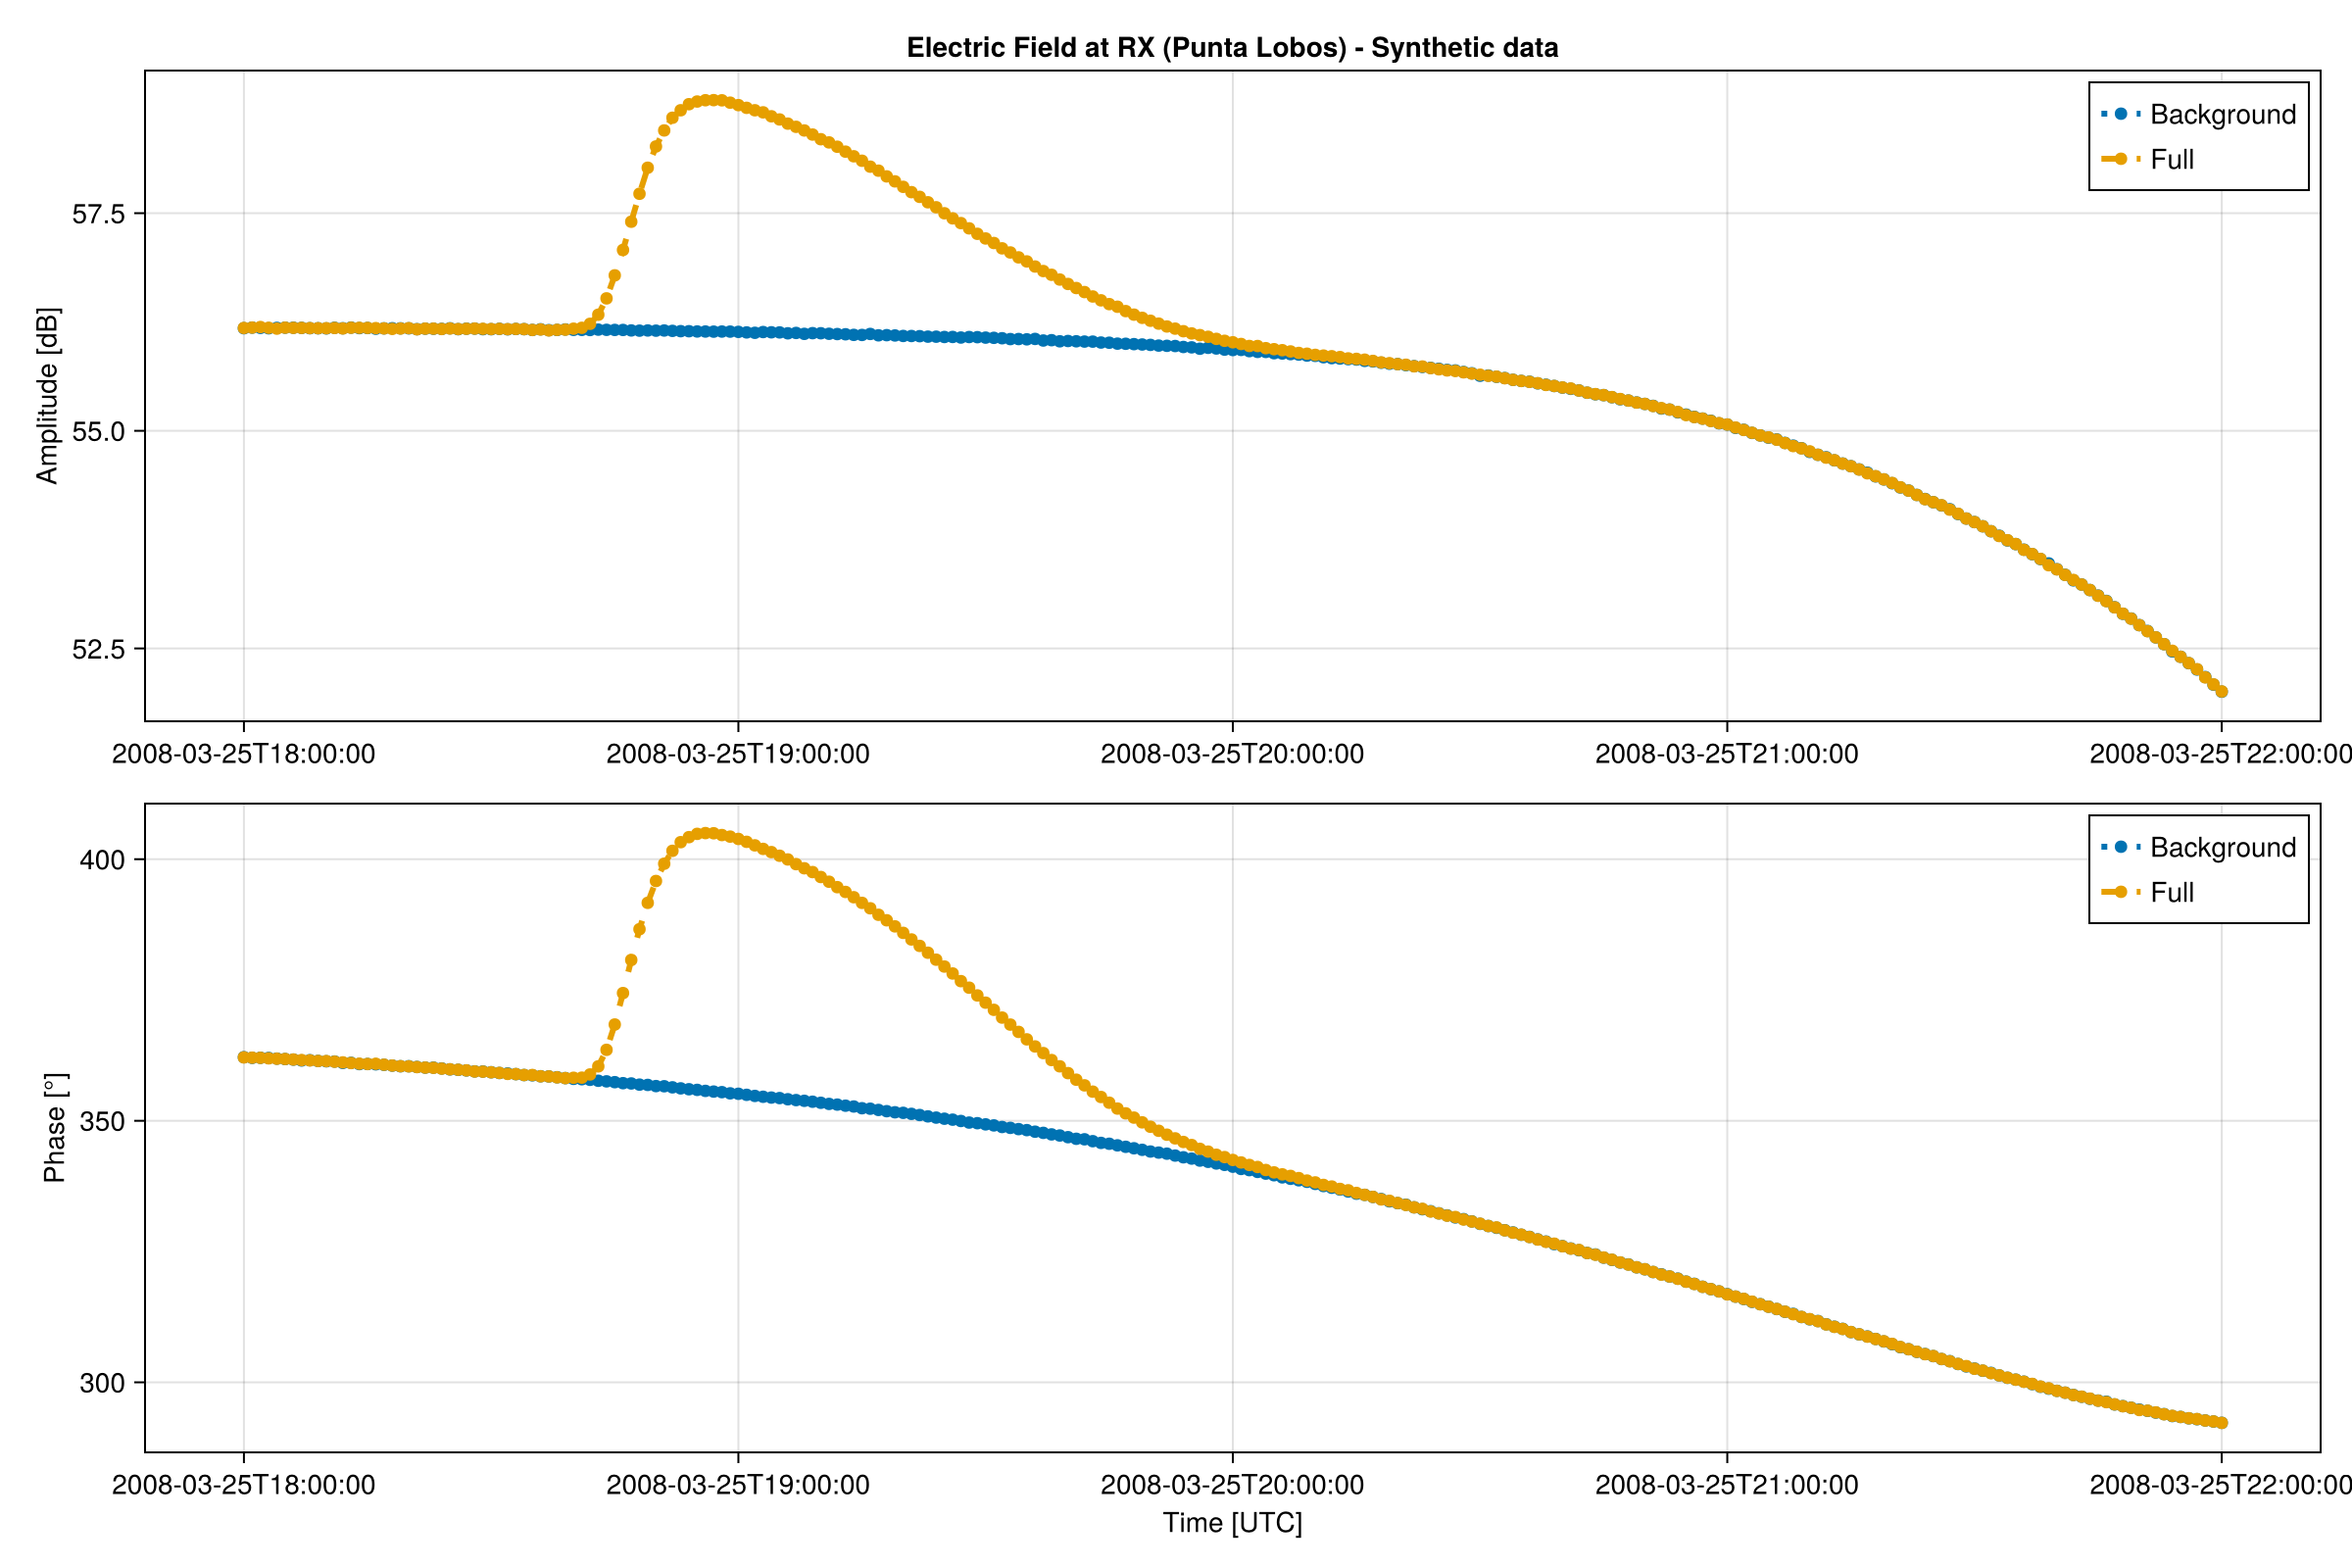

In [8]:
# ============================================================
# 5) COMPARACIÓN VISUAL: BACKGROUND Y SINTÉTICO vs REAL
# ============================================================
time_axis = DateTime.(zdt_test)

fig = Figure(size = (1200, 800))

ax1 = Axis(fig[1, 1],
    title = "Electric Field at RX (Punta Lobos) - Synthetic data",
    ylabel = "Amplitude [dB]"
)
#lines!(ax1, time_axis, target_A_corr, label = "Real corregida", linewidth = 3)
#scatter!(ax1, time_axis, target_A_corr, markersize = 10)
#lines!(ax1, time_axis, A_bg, label = "Background", linewidth = 3, linestyle = :dot)
scatterlines!(ax1, time_axis, A_bg, markersize = 9,label = "Background", linewidth = 3, linestyle = :dot)
scatterlines!(ax1, time_axis, A_syn, label = "Full", linewidth = 3, linestyle = :dash)
#scatter!(ax1, time_axis, A_syn, markersize = 10)
axislegend(ax1, position = :rt)

ax2 = Axis(fig[2, 1],
    #title = "Fase: background y sintética vs datos reales",
    xlabel = "Time [UTC]",
    ylabel = "Phase [°]"
)
#lines!(ax2, time_axis, target_phi_corr, label = "Real corregida", linewidth = 3)
#scatter!(ax2, time_axis, target_phi_corr, markersize = 10)
scatterlines!(ax2, time_axis, phi_bg, label = "Background", linewidth = 3, linestyle = :dot)
#scatter!(ax2, time_axis, phi_bg, markersize = 9)
scatterlines!(ax2, time_axis, phi_syn, label = "Full", linewidth = 3, linestyle = :dash)
#scatter!(ax2, time_axis, phi_syn, markersize = 10)
axislegend(ax2, position = :rt)

fig


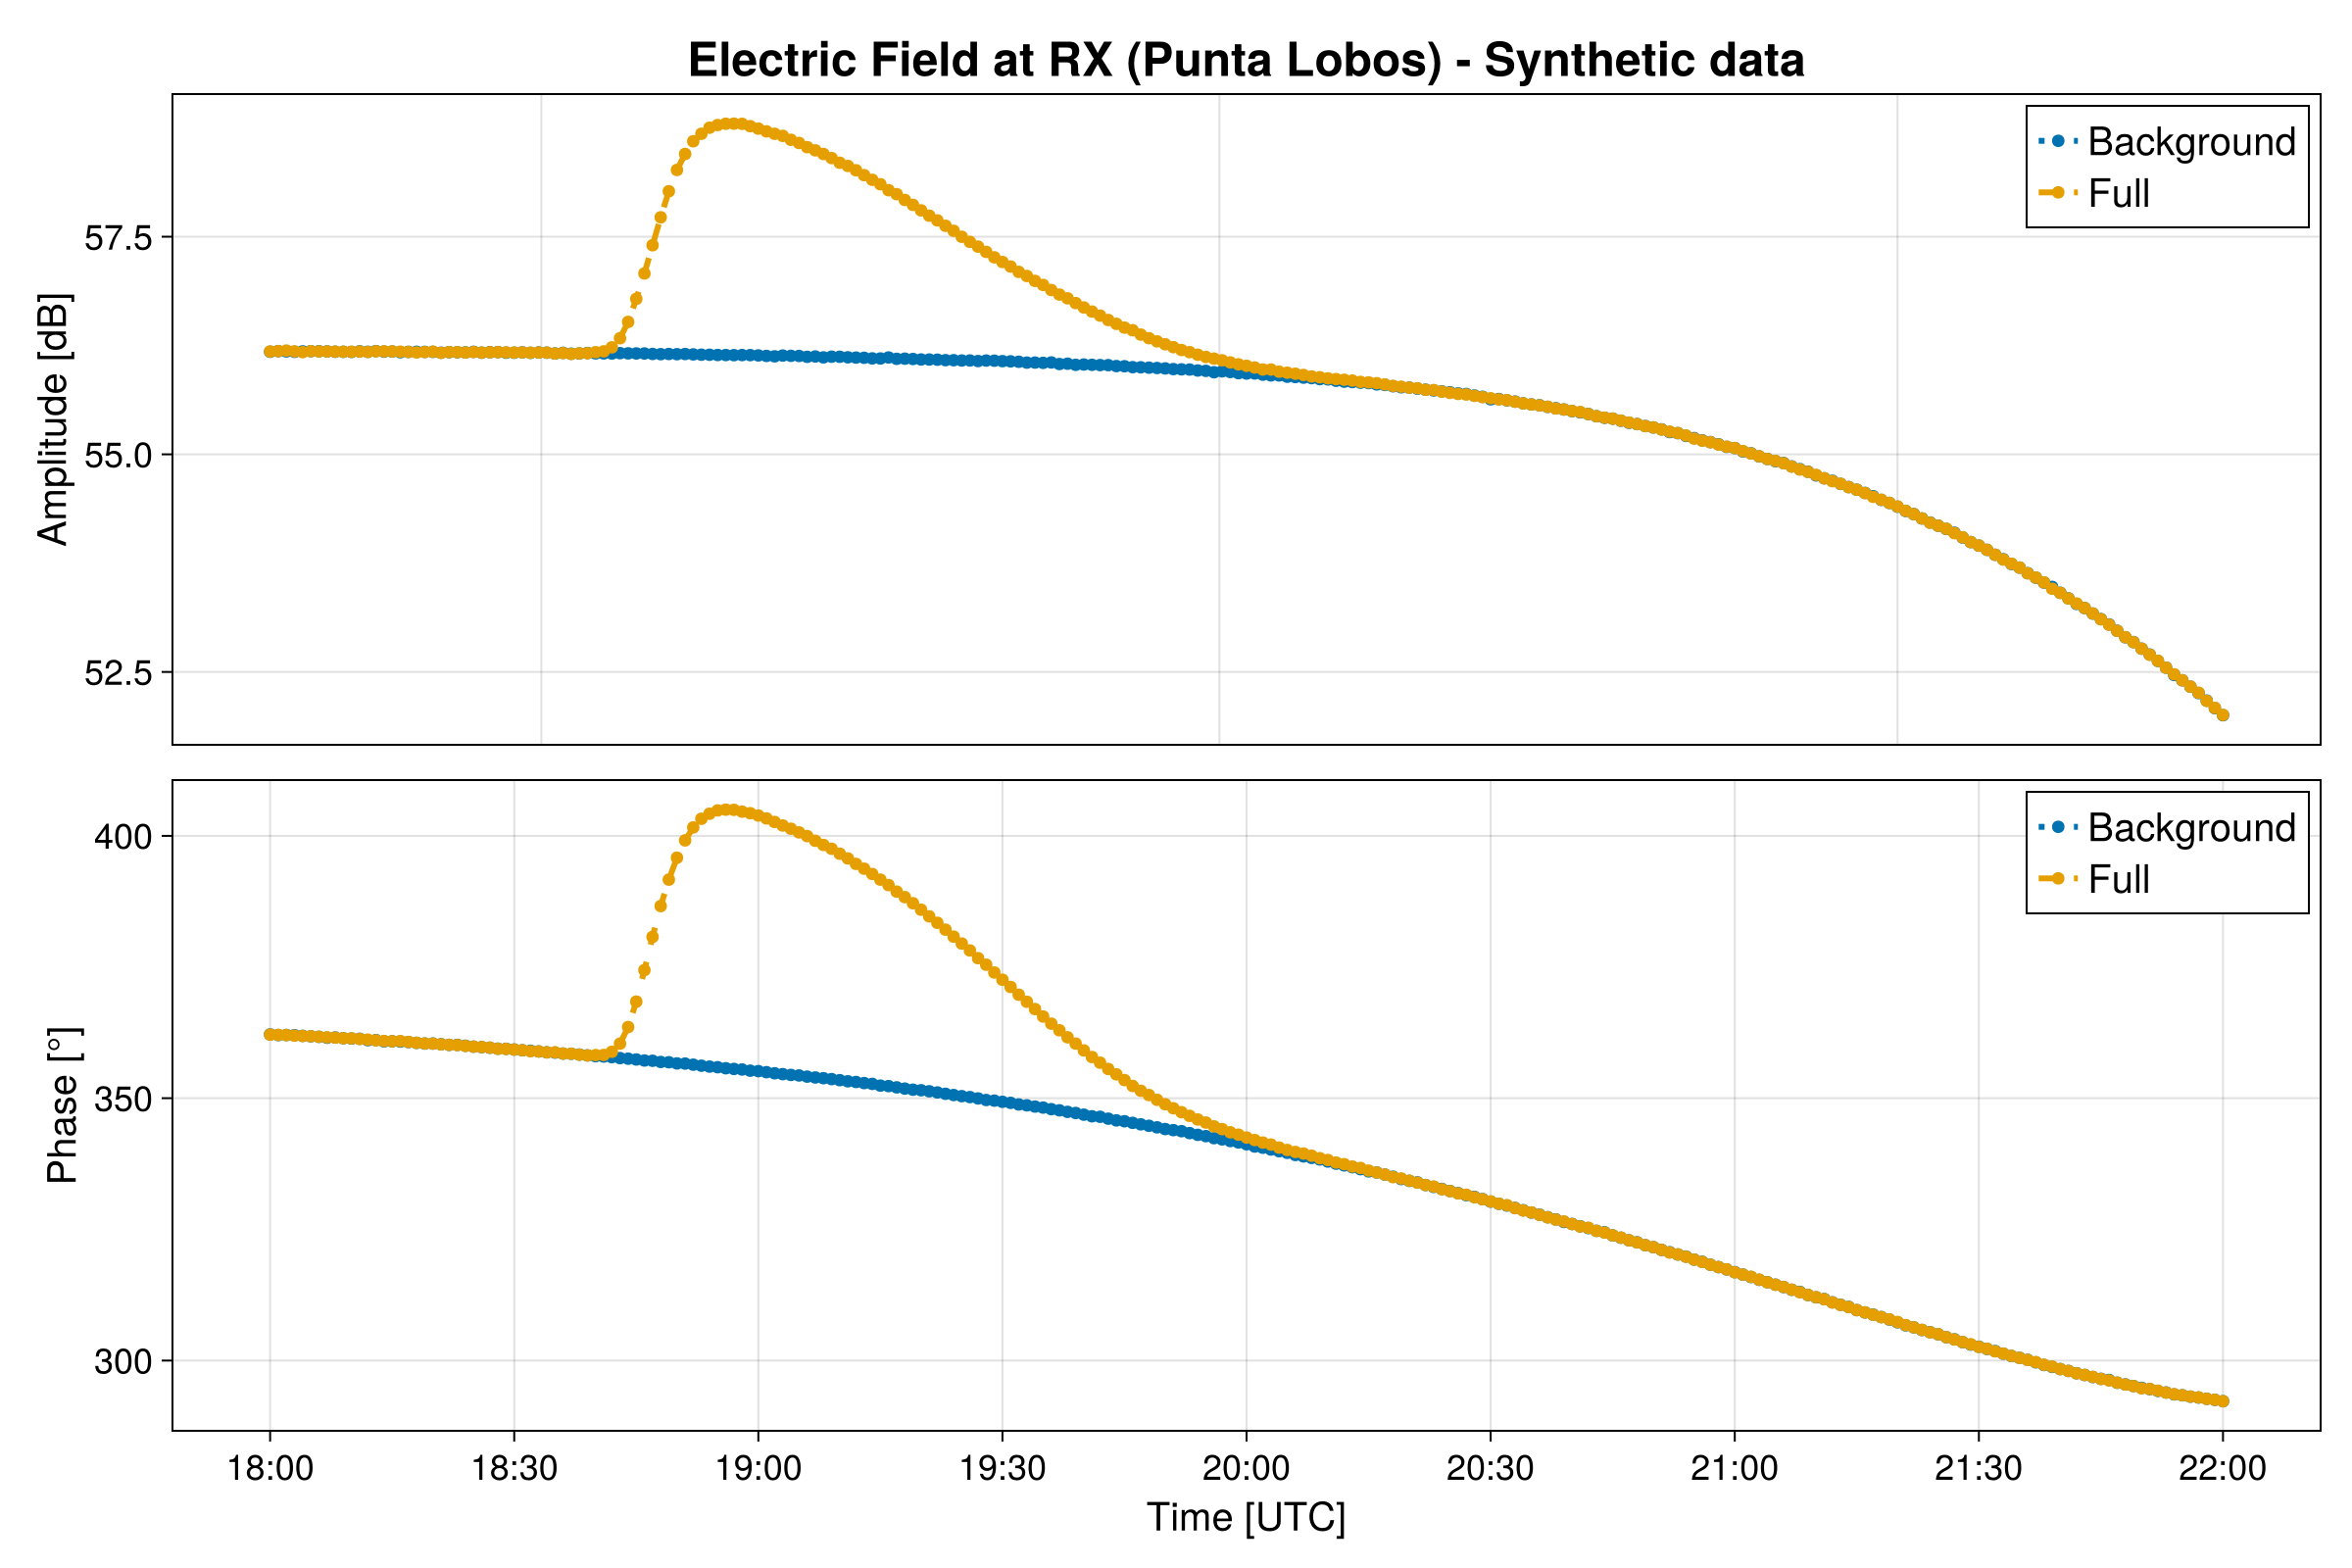

In [15]:
using CairoMakie, Dates

time_axis = DateTime.(zdt_test)
time_num  = Dates.datetime2unix.(time_axis)   # eje X numérico en segundos

# ticks cada 30 min, con labels HH:MM
tini = ceil(first(time_axis), Minute(30))
tfin = floor(last(time_axis), Minute(30))
xticks_dt     = collect(tini:Minute(30):tfin)
xticks_num    = Dates.datetime2unix.(xticks_dt)
xtick_labels  = Dates.format.(xticks_dt, "HH:MM")

fig = Figure(size = (1200, 800))

ax1 = Axis(
    fig[1, 1],
    title = "Electric Field at RX (Punta Lobos) - Synthetic data",
    ylabel = "Amplitude [dB]",
    xticklabelsize = 18,
    yticklabelsize = 18,
    xlabelsize = 20,
    ylabelsize = 20,
    titlesize = 24
)

scatterlines!(ax1, time_num, A_bg,
    markersize = 9,
    label = "Background",
    linewidth = 3,
    linestyle = :dot
)

scatterlines!(ax1, time_num, A_syn,
    label = "Full",
    linewidth = 3,
    linestyle = :dash
)

axislegend(ax1, position = :rt,labelsize=20)

ax2 = Axis(
    fig[2, 1],
    xlabel = "Time [UTC]",
    ylabel = "Phase [°]",
    xticks = (xticks_num, xtick_labels),
    xticklabelsize = 18,
    yticklabelsize = 18,
    xlabelsize = 20,
    ylabelsize = 20,
    titlesize = 24
)

scatterlines!(ax2, time_num, phi_bg,
    label = "Background",
    linewidth = 3,
    linestyle = :dot
)

scatterlines!(ax2, time_num, phi_syn,
    label = "Full",
    linewidth = 3,
    linestyle = :dash
)

axislegend(ax2, position = :rt,labelsize=20)

linkxaxes!(ax1, ax2)
hidexdecorations!(ax1, grid = false)

fig

In [10]:
# ============================================================
# 6) TABLA RESUMEN Y GUARDADO DEL RESULTADO SINTÉTICO
# ============================================================
summary_matrix = hcat(
    Float64.(timestamps_test),
    target_A,
    target_phi,
    target_A_corr,
    target_phi_corr,
    A_bg,
    phi_bg,
    A_syn,
    phi_syn
)

open("synthetic_vs_real_F3_nexp_seed-fine2.csv", "w") do io
    println(io, "unix_time,target_A_raw,target_phi_raw,target_A_corr,target_phi_corr,A_bg,phi_bg,A_syn,phi_syn")
    for row in eachrow(summary_matrix)
        println(io, join(row, ","))
    end
end

h5open("synthetic_F3_nexp_seed_fine2.h5", "w") do f
    write(f, "timestamps", Float64.(timestamps_test))
    write(f, "A_bg", Float64.(A_bg))
    write(f, "phi_bg", Float64.(phi_bg))
    write(f, "A_syn", Float64.(A_syn))
    write(f, "phi_syn", Float64.(phi_syn))
    write(f, "target_A_raw", Float64.(target_A))
    write(f, "target_phi_raw", Float64.(target_phi))
    write(f, "target_A_corr", Float64.(target_A_corr))
    write(f, "target_phi_corr", Float64.(target_phi_corr))
    write(f, "pars_syn", Float64.(pars_syn))
    write(f, "coeffs_h_alb", Float64.(coeffs_h_alb))
    write(f, "coeffs_beta_alb", Float64.(coeffs_β_alb))
    HDF5.attributes(f)["model"] = "F3_gaussiana_asimetrica_nexp_vertical"
    HDF5.attributes(f)["note"] = "Serie sintética perturbada y serie background generadas con el mismo background ionosférico del script real"
end

println("Archivos guardados:")
println(" - synthetic_vs_real_F3_nexp_seed-fine2.csv")
println(" - synthetic_F3_nexp_seed_fine2.h5")


Archivos guardados:
 - synthetic_vs_real_F3_nexp_seed-fine2.csv
 - synthetic_F3_nexp_seed_fine2.h5


In [11]:
using HDF5, Dates

filename = "synthetic_F3_nexp_seed_fine2.h5"
@assert isfile(filename) "No existe el archivo: $filename"

synthetic = h5open(filename, "r") do f
    data = Dict{String,Any}()
    for name in keys(f)
        data[String(name)] = read(f[name])
    end

    attrs = Dict{String,Any}()
    ats = HDF5.attributes(f)
    for k in keys(ats)
        attrs[String(k)] = try
            read(ats[k])
        catch
            nothing
        end
    end

    (; data, attrs)
end

# ===== aliases correctos para ESTE archivo =====
timestamps       = get(synthetic.data, "timestamps", Float64[]) |> x -> Float64.(x)
time_utc         = isempty(timestamps) ? DateTime[] : unix2datetime.(timestamps)

A_bg             = get(synthetic.data, "A_bg", Float64[]) |> x -> Float64.(x)
phi_bg           = get(synthetic.data, "phi_bg", Float64[]) |> x -> Float64.(x)
A_syn            = get(synthetic.data, "A_syn", Float64[]) |> x -> Float64.(x)
phi_syn          = get(synthetic.data, "phi_syn", Float64[]) |> x -> Float64.(x)

target_A_raw     = get(synthetic.data, "target_A_raw", Float64[]) |> x -> Float64.(x)
target_A_corr    = get(synthetic.data, "target_A_corr", Float64[]) |> x -> Float64.(x)
target_phi_raw   = get(synthetic.data, "target_phi_raw", Float64[]) |> x -> Float64.(x)
target_phi_corr  = get(synthetic.data, "target_phi_corr", Float64[]) |> x -> Float64.(x)

pars_syn         = get(synthetic.data, "pars_syn", Float64[]) |> x -> Float64.(x)
coeffs_h_alb     = get(synthetic.data, "coeffs_h_alb", Float64[]) |> x -> Float64.(x)
coeffs_beta_alb  = get(synthetic.data, "coeffs_beta_alb", Float64[]) |> x -> Float64.(x)

model = get(synthetic.attrs, "model", "")
note  = get(synthetic.attrs, "note", "")

println("Datasets disponibles: ", sort(collect(keys(synthetic.data))))
println("Atributos disponibles: ", sort(collect(keys(synthetic.attrs))))
println("\nmodel = ", model)
println("note  = ", note)

println("\nTamaños:")
println("  timestamps      => ", length(timestamps))
println("  A_bg            => ", length(A_bg))
println("  phi_bg          => ", length(phi_bg))
println("  A_syn           => ", length(A_syn))
println("  phi_syn         => ", length(phi_syn))
println("  target_A_raw    => ", length(target_A_raw))
println("  target_A_corr   => ", length(target_A_corr))
println("  target_phi_raw  => ", length(target_phi_raw))
println("  target_phi_corr => ", length(target_phi_corr))
println("  pars_syn        => ", length(pars_syn))
println("  coeffs_h_alb    => ", length(coeffs_h_alb))
println("  coeffs_beta_alb => ", length(coeffs_beta_alb))

println("\nPrimeras 3 marcas de tiempo UTC:")
println(time_utc[1:min(3, end)])


Datasets disponibles: ["A_bg", "A_syn", "coeffs_beta_alb", "coeffs_h_alb", "pars_syn", "phi_bg", "phi_syn", "target_A_corr", "target_A_raw", "target_phi_corr", "target_phi_raw", "timestamps"]
Atributos disponibles: ["model", "note"]

model = F3_gaussiana_asimetrica_nexp_vertical
note  = Serie sintética perturbada y serie background generadas con el mismo background ionosférico del script real

Tamaños:
  timestamps      => 241
  A_bg            => 241
  phi_bg          => 241
  A_syn           => 241
  phi_syn         => 241
  target_A_raw    => 241
  target_A_corr   => 241
  target_phi_raw  => 241
  target_phi_corr => 241
  pars_syn        => 7
  coeffs_h_alb    => 9
  coeffs_beta_alb => 6

Primeras 3 marcas de tiempo UTC:
[DateTime("2008-03-25T18:00:00"), DateTime("2008-03-25T18:01:00"), DateTime("2008-03-25T18:02:00")]


In [21]:
target_phi_corr

241-element Vector{Float64}:
 350.20001220703125
 349.75
 349.96002197265625
 350.02001953125
 349.04998779296875
 349.22998046875
 348.6400146484375
 348.8499755859375
 349.72998046875
 349.59002685546875
 349.80999755859375
 349.52001953125
 349.07000732421875
   ⋮
 315.6199951171875
 314.969970703125
 313.79998779296875
 313.719970703125
 313.239990234375
 313.58001708984375
 313.6099853515625
 312.82000732421875
 313.02001953125
 312.52001953125
 311.71002197265625
 311.6099853515625

In [22]:
phi_syn

241-element Vector{Float64}:
 362.16113549485937
 362.0461173696962
 362.0784844387132
 361.9347472760911
 361.8667771716061
 361.72574987194344
 361.72478406029956
 361.56923692141186
 361.57759690574494
 361.4369108866563
 361.3960428381024
 361.2886737471601
 361.1649459516431
   ⋮
 295.1146906356335
 294.69711281798465
 294.569282944156
 294.2333159077606
 293.88578666510057
 293.59781332166955
 293.3810163774169
 293.12508346087
 292.9224540232235
 292.7495433033859
 292.5317882178193
 292.23738907820217

In [23]:
pars_syn

7-element Vector{Float64}:
   20.0
 1609.4725200000003
  190.5781464
 1248.558552
  789.6851280000001
   85.0
   10.0